In [2]:
!pip install pmdarima

In [3]:
!pip install keras-tcn


In [4]:
# ===============================================================
# 🧠 Step 1: Import Libraries
# ===============================================================
print("="*60)
print("🧠 STEP 1 START: Importing libraries...")
print("="*60)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import timedelta
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tcn import TCN

print("✅ STEP 1 COMPLETE: Libraries imported")



🧠 STEP 1 START: Importing libraries...
✅ STEP 1 COMPLETE: Libraries imported


In [5]:
# ===============================================================
# 🧠 Step 2: Load and Prepare Dataset
# ===============================================================
print("="*60)
print("🧠 STEP 2 START: Loading and preprocessing data...")
print("="*60)

file_path = 'Electric_Vehicle_Charging_Station_Data.csv'
df = pd.read_csv(file_path)

df['Start_Date___Time'] = pd.to_datetime(df['Start_Date___Time'], format='mixed')
df['End_Date___Time']   = pd.to_datetime(df['End_Date___Time'], format='mixed')

df['Charging_Time__hh_mm_ss_'] = pd.to_timedelta(df['Charging_Time__hh_mm_ss_'])
df['Charging_Hours'] = df['Charging_Time__hh_mm_ss_'].dt.total_seconds() / 3600
df['Charging_Hours'] = df['Charging_Hours'].replace(0, np.nan)

df['Energy_per_Hour'] = df['Energy__kWh_'] / df['Charging_Hours']
df = df.dropna(subset=['Start_Date___Time', 'End_Date___Time', 'Energy_per_Hour'])

start_date = df['Start_Date___Time'].min().floor('H')
end_date   = df['End_Date___Time'].max().ceil('H')
hourly_index = pd.date_range(start=start_date, end=end_date, freq='H')

df_hourly_load = pd.DataFrame(index=hourly_index, columns=['Energy_kWh'])
df_hourly_load['Energy_kWh'] = 0.0

print("⏳ Distributing energy across hourly buckets...")

for _, row in tqdm(df.iterrows(), total=len(df), desc="Energy distribution"):
    current_time = row['Start_Date___Time'].floor('H')
    end_time = row['End_Date___Time'].ceil('H')
    energy_rate = row['Energy_per_Hour']

    while current_time <= end_time:
        next_hour = current_time + timedelta(hours=1)

        start_overlap = max(row['Start_Date___Time'], current_time)
        end_overlap   = min(row['End_Date___Time'], next_hour)

        overlap_seconds = (end_overlap - start_overlap).total_seconds()

        if overlap_seconds > 0 and current_time in df_hourly_load.index:
            df_hourly_load.loc[current_time, 'Energy_kWh'] += (
                overlap_seconds / 3600
            ) * energy_rate

        current_time = next_hour

df_hourly = df_hourly_load.copy()

print("✅ STEP 2 COMPLETE: Hourly load created")


🧠 STEP 2 START: Loading and preprocessing data...


C:\Users\ASUS TUF-Pc\AppData\Local\Temp\ipykernel_18884\247617767.py:21: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  start_date = df['Start_Date___Time'].min().floor('H')
C:\Users\ASUS TUF-Pc\AppData\Local\Temp\ipykernel_18884\247617767.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  end_date   = df['End_Date___Time'].max().ceil('H')
C:\Users\ASUS TUF-Pc\AppData\Local\Temp\ipykernel_18884\247617767.py:23: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_index = pd.date_range(start=start_date, end=end_date, freq='H')


⏳ Distributing energy across hourly buckets...


Energy distribution:   0%|                                                                  | 0/133029 [00:00<?, ?it/s]C:\Users\ASUS TUF-Pc\AppData\Local\Temp\ipykernel_18884\247617767.py:31: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  current_time = row['Start_Date___Time'].floor('H')
C:\Users\ASUS TUF-Pc\AppData\Local\Temp\ipykernel_18884\247617767.py:32: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  end_time = row['End_Date___Time'].ceil('H')
Energy distribution: 100%|████████████████████████████████████████████████████| 133029/133029 [06:04<00:00, 364.48it/s]

✅ STEP 2 COMPLETE: Hourly load created


In [6]:
# ===============================================================
# 🧠 Step 3: Train–Test Split (Time-Based)
# ===============================================================
print("="*60)
print("🧠 STEP 3 START: Creating calendar features & splitting data...")
print("="*60)

df_hourly.index.name = 'Datetime'

df_hourly['hour'] = df_hourly.index.hour
df_hourly['day_of_week'] = df_hourly.index.dayofweek

df_hourly['hour_sin'] = np.sin(2 * np.pi * df_hourly['hour'] / 24)
df_hourly['hour_cos'] = np.cos(2 * np.pi * df_hourly['hour'] / 24)
df_hourly['day_sin']  = np.sin(2 * np.pi * df_hourly['day_of_week'] / 7)
df_hourly['day_cos']  = np.cos(2 * np.pi * df_hourly['day_of_week'] / 7)

data = df_hourly['Energy_kWh']
features = df_hourly[['hour_sin', 'hour_cos', 'day_sin', 'day_cos']]

split_point = int(len(data) * 0.8)

train = data.iloc[:split_point]
test  = data.iloc[split_point:]

train_features = features.iloc[:split_point]
test_features  = features.iloc[split_point:]

print("✅ STEP 3 COMPLETE")


🧠 STEP 3 START: Creating calendar features & splitting data...
✅ STEP 3 COMPLETE


In [7]:
# ===============================================================
# 🧠 Step 4: Feature Scaling
# ===============================================================
print("="*60)
print("🧠 STEP 4 START: Scaling data...")
print("="*60)

y_scaler = StandardScaler()
x_scaler = StandardScaler()

y_train = y_scaler.fit_transform(train.values.reshape(-1,1))
y_test  = y_scaler.transform(test.values.reshape(-1,1))

X_train_feat = x_scaler.fit_transform(train_features)
X_test_feat  = x_scaler.transform(test_features)

print("✅ STEP 4 COMPLETE")


🧠 STEP 4 START: Scaling data...
✅ STEP 4 COMPLETE


In [8]:
# ===============================================================
# 🧠 Step 5: Create TCN Sequences (NON-RECURSIVE)
# ===============================================================
print("="*60)
print("🧠 STEP 5 START: Creating TCN sequences...")
print("="*60)

WINDOW_SIZE = 24
HORIZON = 1

def create_sequences(y, X, window, horizon):
    X_seq, y_seq = [], []
    for i in tqdm(range(window, len(y) - horizon + 1), desc="Sequence building"):
        X_window = np.hstack([y[i-window:i], X[i-window:i]])
        X_seq.append(X_window)
        y_seq.append(y[i:i+horizon])
    return np.array(X_seq), np.array(y_seq)

X_train, y_train_seq = create_sequences(y_train, X_train_feat, WINDOW_SIZE, HORIZON)
X_test,  y_test_seq  = create_sequences(y_test,  X_test_feat,  WINDOW_SIZE, HORIZON)

print("✅ STEP 5 COMPLETE")


🧠 STEP 5 START: Creating TCN sequences...


Sequence building: 100%|█████████████████████████████████████████████████████| 10361/10361 [00:00<00:00, 102804.20it/s]

✅ STEP 5 COMPLETE


In [9]:
# ===============================================================
# 🧠 Step 6: Build TCN-Only Model
# ===============================================================
print("="*60)
print("🧠 STEP 6 START: Building TCN model...")
print("="*60)

model = Sequential([
    TCN(
        nb_filters=64,
        kernel_size=3,
        dilations=[1, 2, 4, 8, 16],
        dropout_rate=0.2,
        return_sequences=False,
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

model.summary()
print("✅ STEP 6 COMPLETE")


C:\Users\ASUS TUF-Pc\anaconda3\Lib\site-packages\tcn\tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


🧠 STEP 6 START: Building TCN model...



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ tcn (TCN)                            │ (None, 64)                  │         112,576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 114,689 (448.00 KB)

 Trainable params: 114,689 (448.00 KB)

 Non-trainable params: 0 (0.00 B)

✅ STEP 6 COMPLETE


In [10]:
# ===============================================================
# 🧠 Step 7: Train the TCN Model
# ===============================================================
print("="*60)
print("🧠 STEP 7 START: Training TCN...")
print("="*60)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=100,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train_seq,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

print("✅ STEP 7 COMPLETE")


🧠 STEP 7 START: Training TCN...
Epoch 1/300
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 40s 27ms/step - loss: 1.3986 - val_loss: 0.6446
Epoch 2/300
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - loss: 0.2523 - val_loss: 0.5254
Epoch 3/300
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 25s 24ms/step - loss: 0.1975 - val_loss: 0.5146
Epoch 4/300
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - loss: 0.1751 - val_loss: 0.4562
Epoch 5/300
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - loss: 0.1628 - val_loss: 0.3686
Epoch 6/300
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - loss: 0.1567 - val_loss: 0.3816
Epoch 7/300
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - loss: 0.1530 - val_loss: 0.3813
Epoch 8/300
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - loss: 0.1506 - val_loss: 0.3073
Epoch 9/300
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - loss: 0.1478 - val_loss: 0.3655
Epoch 10/300
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 27s 26ms/step - loss: 0.1450 - val_loss: 0.3771
Epoch 11/300
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 48s 33ms/step

In [11]:
# ===============================================================
# 🧠 Step 8: Make Predictions
# ===============================================================
print("="*60)
print("🧠 STEP 8 START: Generating predictions...")
print("="*60)

y_pred_scaled = model.predict(X_test)
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_true = y_scaler.inverse_transform(y_test_seq.reshape(-1,1))

print("✅ STEP 8 COMPLETE")


🧠 STEP 8 START: Generating predictions...
324/324 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step
✅ STEP 8 COMPLETE


In [12]:
# ===============================================================
# 🧠 Step 9: Model Evaluation
# ===============================================================
print("="*60)
print("🧠 STEP 9 START: Evaluating model...")
print("="*60)

from sklearn.metrics import r2_score

# --- Core error metrics ---
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

# --- SMAPE implementation ---
def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred) / np.maximum(denominator, 1e-8)
    return np.mean(diff) * 100

smape_value = smape(y_true, y_pred)

# --- Print results ---
print(f"MAE   : {mae:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"R²    : {r2:.4f}")
print(f"SMAPE : {smape_value:.2f}%")

print("✅ STEP 9 COMPLETE")



🧠 STEP 9 START: Evaluating model...
MAE   : 10.1807
RMSE  : 14.7894
R²    : 0.8718
SMAPE : 14.44%
✅ STEP 9 COMPLETE


🧠 STEP 10 START: Plotting results (Full & Zoomed)...


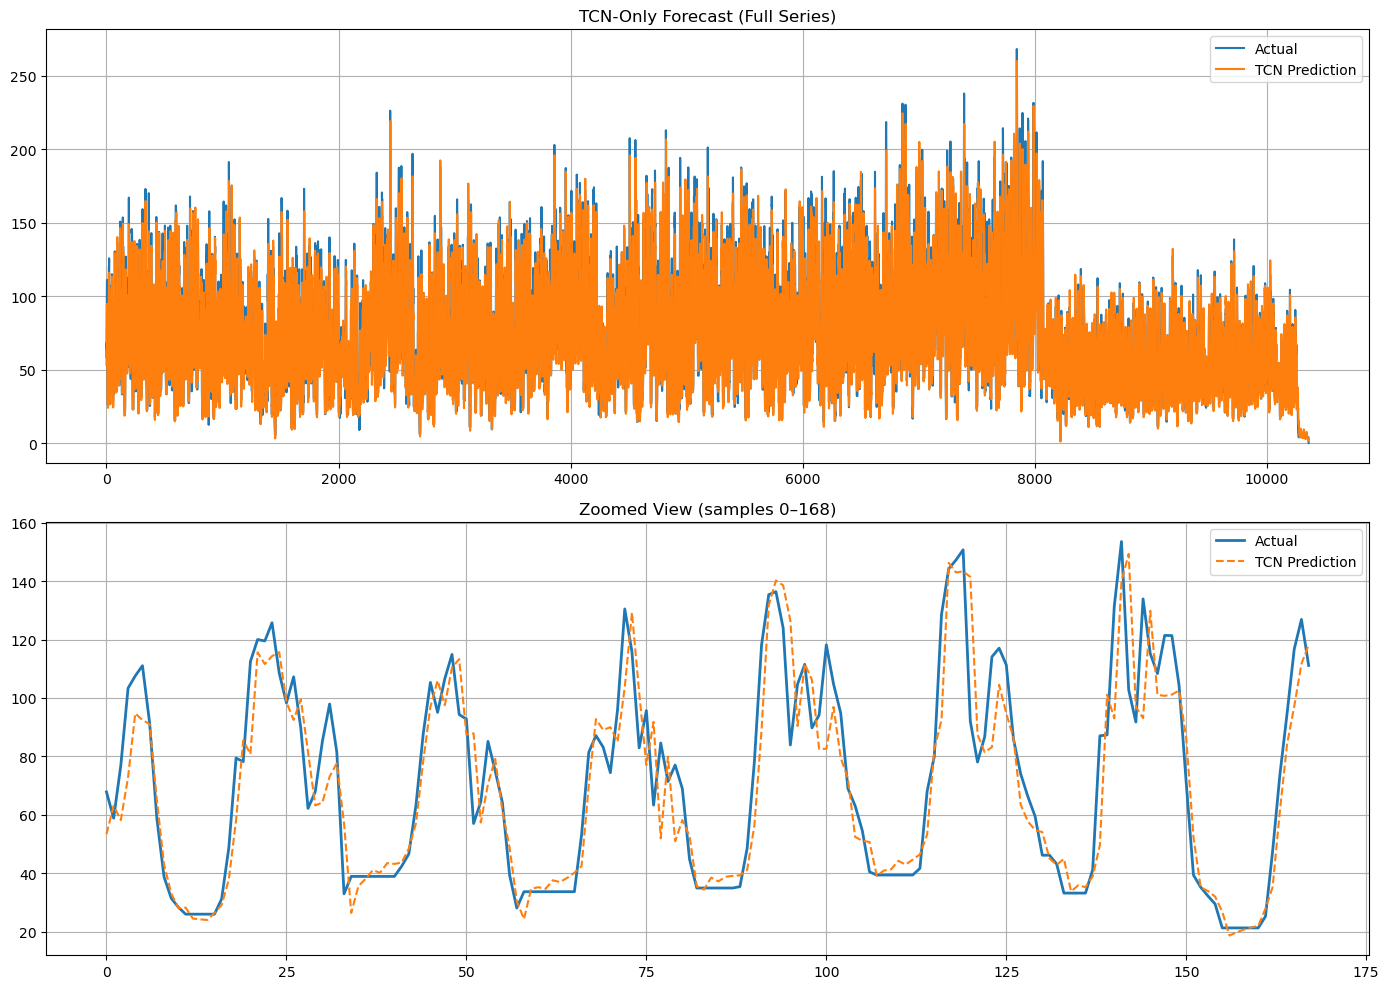

✅ STEP 10 COMPLETE (Full & Zoomed)


In [13]:
# ===============================================================
# 🧠 Step 10: Plot Predictions vs Actual (Full + Zoomed)
# ===============================================================
print("="*60)
print("🧠 STEP 10 START: Plotting results (Full & Zoomed)...")
print("="*60)

zoom_start = 0
zoom_end = 168

plt.figure(figsize=(14,10))

# ---- FULL SERIES ----
plt.subplot(2, 1, 1)
plt.plot(y_true, label='Actual')
plt.plot(y_pred, label='TCN Prediction')
plt.title('TCN-Only Forecast (Full Series)')
plt.legend()
plt.grid(True)

# ---- ZOOMED SERIES ----
plt.subplot(2, 1, 2)
plt.plot(y_true[zoom_start:zoom_end], label='Actual', linewidth=2)
plt.plot(y_pred[zoom_start:zoom_end], label='TCN Prediction', linestyle='--')
plt.title(f'Zoomed View (samples {zoom_start}–{zoom_end})')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("✅ STEP 10 COMPLETE (Full & Zoomed)")


In [14]:
# ===============================================================
# 🧠 Step 11: Save Model (For Thesis Reproducibility)
# ===============================================================
#FIX 1 (RECOMMENDED): Use the native Keras format
print("="*60)
print("🧠 STEP 11 START: Saving model (Keras format)...")
print("="*60)

model.save("TCN_only_model.keras")

print("✅ STEP 11 COMPLETE — PIPELINE FINISHED SUCCESSFULLY")
print("="*60)


🧠 STEP 11 START: Saving model (Keras format)...
✅ STEP 11 COMPLETE — PIPELINE FINISHED SUCCESSFULLY


In [15]:
#FIX 2 (ALSO VALID): Save weights only (most robust)

print("="*60)
print("🧠 STEP 11 START: Saving model weights only...")
print("="*60)

model.save_weights("TCN_only_weights.weights.h5")

print("✅ STEP 11 COMPLETE — PIPELINE FINISHED SUCCESSFULLY")
print("="*60)


🧠 STEP 11 START: Saving model weights only...
✅ STEP 11 COMPLETE — PIPELINE FINISHED SUCCESSFULLY
